In [1]:
from landlab import RasterModelGrid,  imshow_grid
from landlab.plot.graph import plot_graph
import matplotlib.pyplot as plt

<Axes: xlabel='x', ylabel='y'>

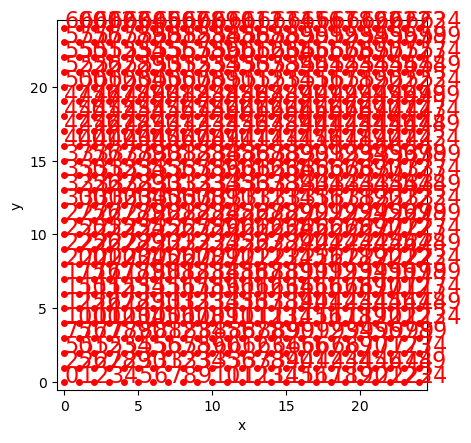

In [2]:
nrows = 25 #grid number of rows
ncols = 25 #grid number of columns
dx = 1 #grid cell spacing
grid = RasterModelGrid((nrows, ncols), dx)
plot_graph(grid, at="node")

In [3]:
temp = grid.add_zeros("temp", at="node")

In [4]:
grid.at_node["temp"][grid.x_of_node<=25-grid.y_of_node] = -1

In [5]:
# temp[(4, 1),] = -1
# temp[(8, 5, 2),] = -2
# temp[(12, 9, 6, 3),] = -3
# temp[(10),] = -4
# temp[(7, 11, 13, 14, 15),] = 5
grid.set_closed_boundaries_at_grid_edges(True, True, True, True)
grid.at_node["temp"] #sanity check

array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1.,  0., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1.,  0.,  0., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1.,  0.,  0.,  0., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1.,  0.,  0.,  0.,  0., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1.,  0.,  0.,  0.,  0.,  0., -1., -1., -1., -1., -1., -1

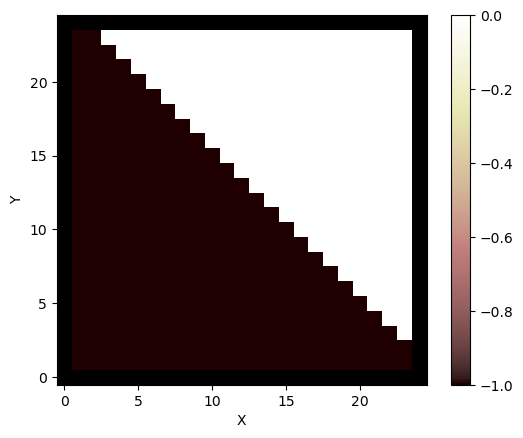

In [6]:
grid.imshow(temp)

In [7]:
is_clay = grid.at_node["temp"] == -1 #define frozen clay nodes
is_air = temp[grid.at_node["temp"] == 0] = 15 #set air nodes to 15 deg Celsius

Text(0, 0.5, 'Depth (m)')

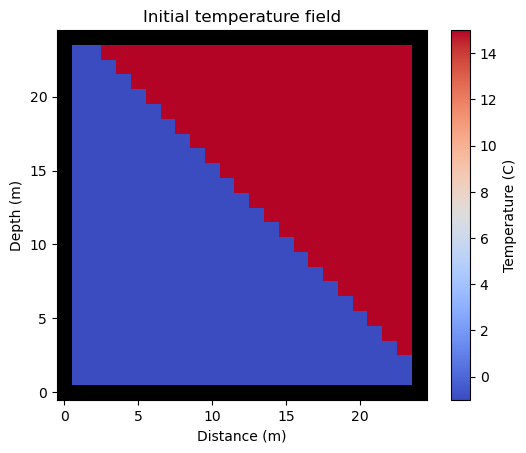

In [11]:
#Plotting initial temperature conditions
fig, ax = plt.subplots()
imshow_grid(
    grid,
    temp,
    cmap="coolwarm",
    vmin=-1,
    vmax=15,
    colorbar_label="Temperature (C)",
)
plt.title("Initial temperature field")
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
#ax.invert_yaxis()